In [1]:
import os
import io
import time
import json
import requests
import urllib3
import pandas as pd
import numpy as np
from pathlib import Path
from datetime import datetime, timedelta
from tqdm import tqdm  
from dotenv import load_dotenv

load_dotenv()
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

LOCAL_PROXY_PORT = "7890"  #  VPN 代理端口
AV_KEY = os.getenv("ALPHA_VANTAGE_KEY")

# 绝对路径对齐
PROJECT_ROOT = Path.cwd().parent if "notebooks" in os.getcwd() else Path.cwd()
BASELINE_CSV_PATH = PROJECT_ROOT / "data" / "processed" / "features_with_bsm_baseline.csv"
CACHE_CSV_PATH = PROJECT_ROOT / "data" / "processed" / "cme_actual_cache.csv"

# 严格锁定 75次/分钟 API 速率（冗余：1.05 秒/次，约为 57 次/分钟）
RATE_LIMIT_DELAY = 1.05  
# ==========================================================

def get_session_with_proxy():
    session = requests.Session()
    if not os.getenv('GITHUB_ACTIONS'):
        proxies = {
            "http": f"http://127.0.0.1:{LOCAL_PROXY_PORT}",
            "https": f"http://127.0.0.1:{LOCAL_PROXY_PORT}"
        }
        session.proxies.update(proxies)
    return session

def fetch_single_day_chooser(session, date_str, s0, r, q, strike=150.0, t1=0.5, t2=1.0, max_retries=3):
    """
    抓取单日 JPM 真实期权链，并计算合成的选择权期权价格。
    支持自动指数退避重试（Exponential Backoff）
    """
    url = f"https://www.alphavantage.co/query?function=HISTORICAL_OPTIONS&symbol=JPM&date={date_str}&apikey={AV_KEY}"
    
    for attempt in range(max_retries):
        try:
            response = session.get(url, timeout=25, verify=False)
            if response.status_code != 200:
                raise requests.exceptions.RequestException(f"HTTP Error {response.status_code}")
                
            res_json = response.json()
            # Alpha Vantage 偶发性提示 Rate Limit 保护
            if "Note" in res_json or "Information" in res_json:
                print(f"\n 触发 API 频控保护，静默等待 10 秒后重试...")
                time.sleep(10)
                continue
                
            option_data = res_json.get("data", [])
            if not option_data:
                # 某些特殊的交易所休市日或无高频报价日，安全返回 NaN
                return np.nan
                
            # 解析期权数据
            df_options = pd.DataFrame(option_data)
            df_options['strike'] = df_options['strike'].astype(float)
            df_options['expiration'] = pd.to_datetime(df_options['expiration'])
            df_options['bid'] = df_options['bid'].astype(float)
            df_options['ask'] = df_options['ask'].astype(float)
            df_options['mid_price'] = (df_options['bid'] + df_options['ask']) / 2.0
            
            eval_dt = pd.to_datetime(date_str)
            
            # 1. 匹配 Put 边 (T2 = 1.0, Strike = 150)
            target_put_expiry = eval_dt + timedelta(days=int(365 * t2))
            df_puts = df_options[(df_options['type'] == 'put') & (df_options['strike'] == strike)]
            if df_puts.empty:
                df_puts = df_options[df_options['type'] == 'put']
                df_puts = df_puts.loc[(df_puts['strike'] - strike).abs().idxmin()]
                df_puts = pd.DataFrame([df_puts])
            best_put_row = df_puts.loc[(df_puts['expiration'] - target_put_expiry).abs().idxmin()]
            real_put_price = best_put_row['mid_price']
            
            # 2. 匹配 Call 边 (T1 = 0.5, Strike' = X * exp(-(r-q)*(T2-T1)))
            target_call_expiry = eval_dt + timedelta(days=int(365 * t1))
            strike_prime = strike * np.exp(-(r - q) * (t2 - t1))
            df_calls = df_options[df_options['type'] == 'call']
            closest_strike = df_calls.loc[(df_calls['strike'] - strike_prime).abs().idxmin()]['strike']
            df_calls_at_strike = df_calls[df_calls['strike'] == closest_strike]
            best_call_row = df_calls_at_strike.loc[(df_calls_at_strike['expiration'] - target_call_expiry).abs().idxmin()]
            real_call_price = best_call_row['mid_price']
            
            # 3. 合成选择权价格
            real_chooser = np.exp(-q * (t2 - t1)) * real_call_price + real_put_price
            return round(real_chooser, 4)
            
        except Exception as e:
            if attempt < max_retries - 1:
                # 指数避让重试
                wait_time = (attempt + 1) * 3
                time.sleep(wait_time)
            else:
                print(f"\n 日期 {date_str} 抓取失败，原因: {e}")
                return np.nan

def run_pipeline():
    # 1. 检查特征大表是否存在
    if not BASELINE_CSV_PATH.exists():
        raise FileNotFoundError(f"未找到特征基础表 {BASELINE_CSV_PATH}。")
    
    df_baseline_raw = pd.read_csv(BASELINE_CSV_PATH, parse_dates=['Date']).set_index('Date')
    df_baseline = df_baseline_raw.loc['2018-01-01':'2024-12-31'].copy()
    all_trading_dates = df_baseline.index.strftime('%Y-%m-%d').tolist()
    
    # 2. 载入或初始化本地增量缓存
    if CACHE_CSV_PATH.exists():
        df_cache = pd.read_csv(CACHE_CSV_PATH, parse_dates=['Date']).set_index('Date')
        print(f"检测到本地缓存，已完成 {len(df_cache)} 个交易日的抓取。")
    else:
        df_cache = pd.DataFrame(columns=['CME_Actual_Price'], index=pd.to_datetime([])).rename_axis('Date')
        df_cache.to_csv(CACHE_CSV_PATH)
        print("未检测到本地缓存，正在新建 CME_Actual 增量备份系统...")

    # 3. 过滤出剩余需要抓取的日期
    cached_dates_set = set(df_cache.index.strftime('%Y-%m-%d').tolist())
    dates_to_fetch = [d for d in all_trading_dates if d not in cached_dates_set]
    
    if not dates_to_fetch:
        print(" 所有 2018-2024 的交易日数据已 100% 抓取完毕，无须重复请求！")
        return

    print(f" 剩余待抓取交易日: {len(dates_to_fetch)} 天。预计消耗时间: {round(len(dates_to_fetch) * RATE_LIMIT_DELAY / 60, 1)} 分钟")
    
    session = get_session_with_proxy()
    
    # 4. 增量批量迭代抓取
    try:
        for date_str in tqdm(dates_to_fetch, desc="JPM 真实期权数据抓取"):
            start_time = time.time()
            
            # 获取当天的特征状态，用于 Call 组件的动态行权价 $X'$ 匹配
            row = df_baseline.loc[date_str]
            s0 = row['JPM_Close']
            r = row['Risk_Free_Rate']
            q = row['Dividend_Growth_Proxy']
            
            # 运行抓取
            real_price = fetch_single_day_chooser(session, date_str, s0, r, q)
            
            # 成功后即刻更新缓存，并实时写入硬盘
            df_cache.loc[pd.to_datetime(date_str), 'CME_Actual_Price'] = real_price
            df_cache.to_csv(CACHE_CSV_PATH)
            
            # 严格限速，确保在一分钟内不会超过 75 次
            elapsed = time.time() - start_time
            sleep_needed = max(0.0, RATE_LIMIT_DELAY - elapsed)
            time.sleep(sleep_needed)
            
    except KeyboardInterrupt:
        print("\n 用户手动中断。当前已抓取的数据已安全存入本地，下次运行将自动续传。")
    
    print("\n 数据抓取阶段结束。")

if __name__ == "__main__":
    if not AV_KEY:
        print(" 未在环境变量中检测到 ALPHA_VANTAGE_KEY，请检查 .env 配置文件！")
    else:
        run_pipeline()

未检测到本地缓存，正在新建 CME_Actual 增量备份系统...
 剩余待抓取交易日: 1763 天。预计消耗时间: 30.9 分钟


JPM 真实期权数据抓取:  16%|████████▊                                              | 282/1763 [06:04<1:59:02,  4.82s/it]


 日期 2019-02-14 抓取失败，原因: attempt to get argmin of an empty sequence


JPM 真实期权数据抓取:  64%|███████████████████████████████████▉                    | 1132/1763 [24:36<57:52,  5.50s/it]


 日期 2022-06-29 抓取失败，原因: ('Connection aborted.', ConnectionResetError(10054, '远程主机强迫关闭了一个现有的连接。', None, 10054, None))


...


 日期 2022-06-30 抓取失败，原因: HTTPSConnectionPool(host='www.alphavantage.co', port=443): Max retries exceeded with url: /query?function=HISTORICAL_OPTIONS&symbol=JPM&date=2022-06-30&apikey=D9GGMB91YUWB7BTB (Caused by SSLError(SSLError(1, '[SSL: WRONG_VERSION_NUMBER] wrong version number (_ssl.c:1000)')))


JPM 真实期权数据抓取:  64%|██████████████████████████████████▋                   | 1134/1763 [25:09<1:58:18, 11.29s/it]


 日期 2022-07-01 抓取失败，原因: ('Connection aborted.', ConnectionResetError(10054, '远程主机强迫关闭了一个现有的连接。', None, 10054, None))


JPM 真实期权数据抓取: 100%|████████████████████████████████████████████████████████| 1763/1763 [40:54<00:00,  1.39s/it]


 数据抓取阶段结束。


In [29]:
# 单元格：合并真实期权成交价并持久化
import pandas as pd
import os
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if "notebooks" in os.getcwd() else Path.cwd()
BASELINE_CSV_PATH = PROJECT_ROOT / "data" / "processed" / "features_with_bsm_baseline.csv"
CACHE_CSV_PATH = PROJECT_ROOT / "data" / "processed" / "cme_actual_cache.csv"
# 1. 载入主特征表与刚刚生成的 CME 真实成交价缓存表
df_baseline = pd.read_csv(BASELINE_CSV_PATH, parse_dates=['Date']).set_index('Date')
df_cache = pd.read_csv(CACHE_CSV_PATH, parse_dates=['Date']).set_index('Date')

# 2. 将真实价格列合并入主特征大表中 
df_baseline['CME_Actual_Price'] = df_cache['CME_Actual_Price']

# 3. 线性填充极个别因交易所临时故障未返回数据的 NaN 空白行
missing_count = df_baseline['CME_Actual_Price'].isna().sum()
if missing_count > 0:
    print(f"发现 {missing_count} 个交易日因休市/缺失未获取到真实数据，正在进行线性内插补齐...")
    df_baseline['CME_Actual_Price'] = df_baseline['CME_Actual_Price'].interpolate(method='linear').ffill().bfill()

# 4. 保存为终极版特征矩阵文件，覆盖原文件
df_baseline.to_csv(BASELINE_CSV_PATH)
print(f" 2018-2024 包含 CME 历史真实成交价的主特征大表已更新并对齐。")
print(df_baseline[['JPM_Close', 'CME_Actual_Price']].tail())

发现 10 个交易日因休市/缺失未获取到真实数据，正在进行线性内插补齐...
 2018-2024 包含 CME 历史真实成交价的主特征大表已更新并对齐。
            JPM_Close  CME_Actual_Price
Date                                   
2024-12-24   235.0186           50.7802
2024-12-26   235.8236           55.0981
2024-12-27   233.9129           53.9872
2024-12-30   232.1186           52.6024
2024-12-31   232.1186           53.1419


In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
from pathlib import Path
import os

PROJECT_ROOT = Path.cwd().parent if "notebooks" in os.getcwd() else Path.cwd()
BASELINE_CSV_PATH = PROJECT_ROOT / "data" / "processed" / "features_with_bsm_baseline.csv"

df_eval = pd.read_csv(BASELINE_CSV_PATH, parse_dates=['Date']).set_index('Date')

print("====================  BSM vs 真实场内成交价 误差计量 ====================")
for t1 in [0.50]:
    pred_column = f"Chooser_BSM_T1_{t1}"
    
    # 剔除空值行进行纯净计算
    mask = df_eval['CME_Actual_Price'].notna() & df_eval[pred_column].notna()
    actual = df_eval.loc[mask, 'CME_Actual_Price'].values
    predicted = df_eval.loc[mask, pred_column].values
    
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    
    print(f" 决策尺度 T1 = {t1} 年:")
    print(f"   - 平均绝对误差 (MAE) : ${mae:.4f} USD")
    print(f"   - 均方根误差 (RMSE)  : ${rmse:.4f} USD")
    print(f"   - 平均百分比误差 (MAPE): {mape:.2f}%")
    print("-" * 55)

====================  BSM vs 真实场内成交价 误差计量 ====================
 决策尺度 T1 = 0.5 年:
   - 平均绝对误差 (MAE) : $14.5879 USD
   - 均方根误差 (RMSE)  : $17.2037 USD
   - 平均百分比误差 (MAPE): 48.69%
-------------------------------------------------------


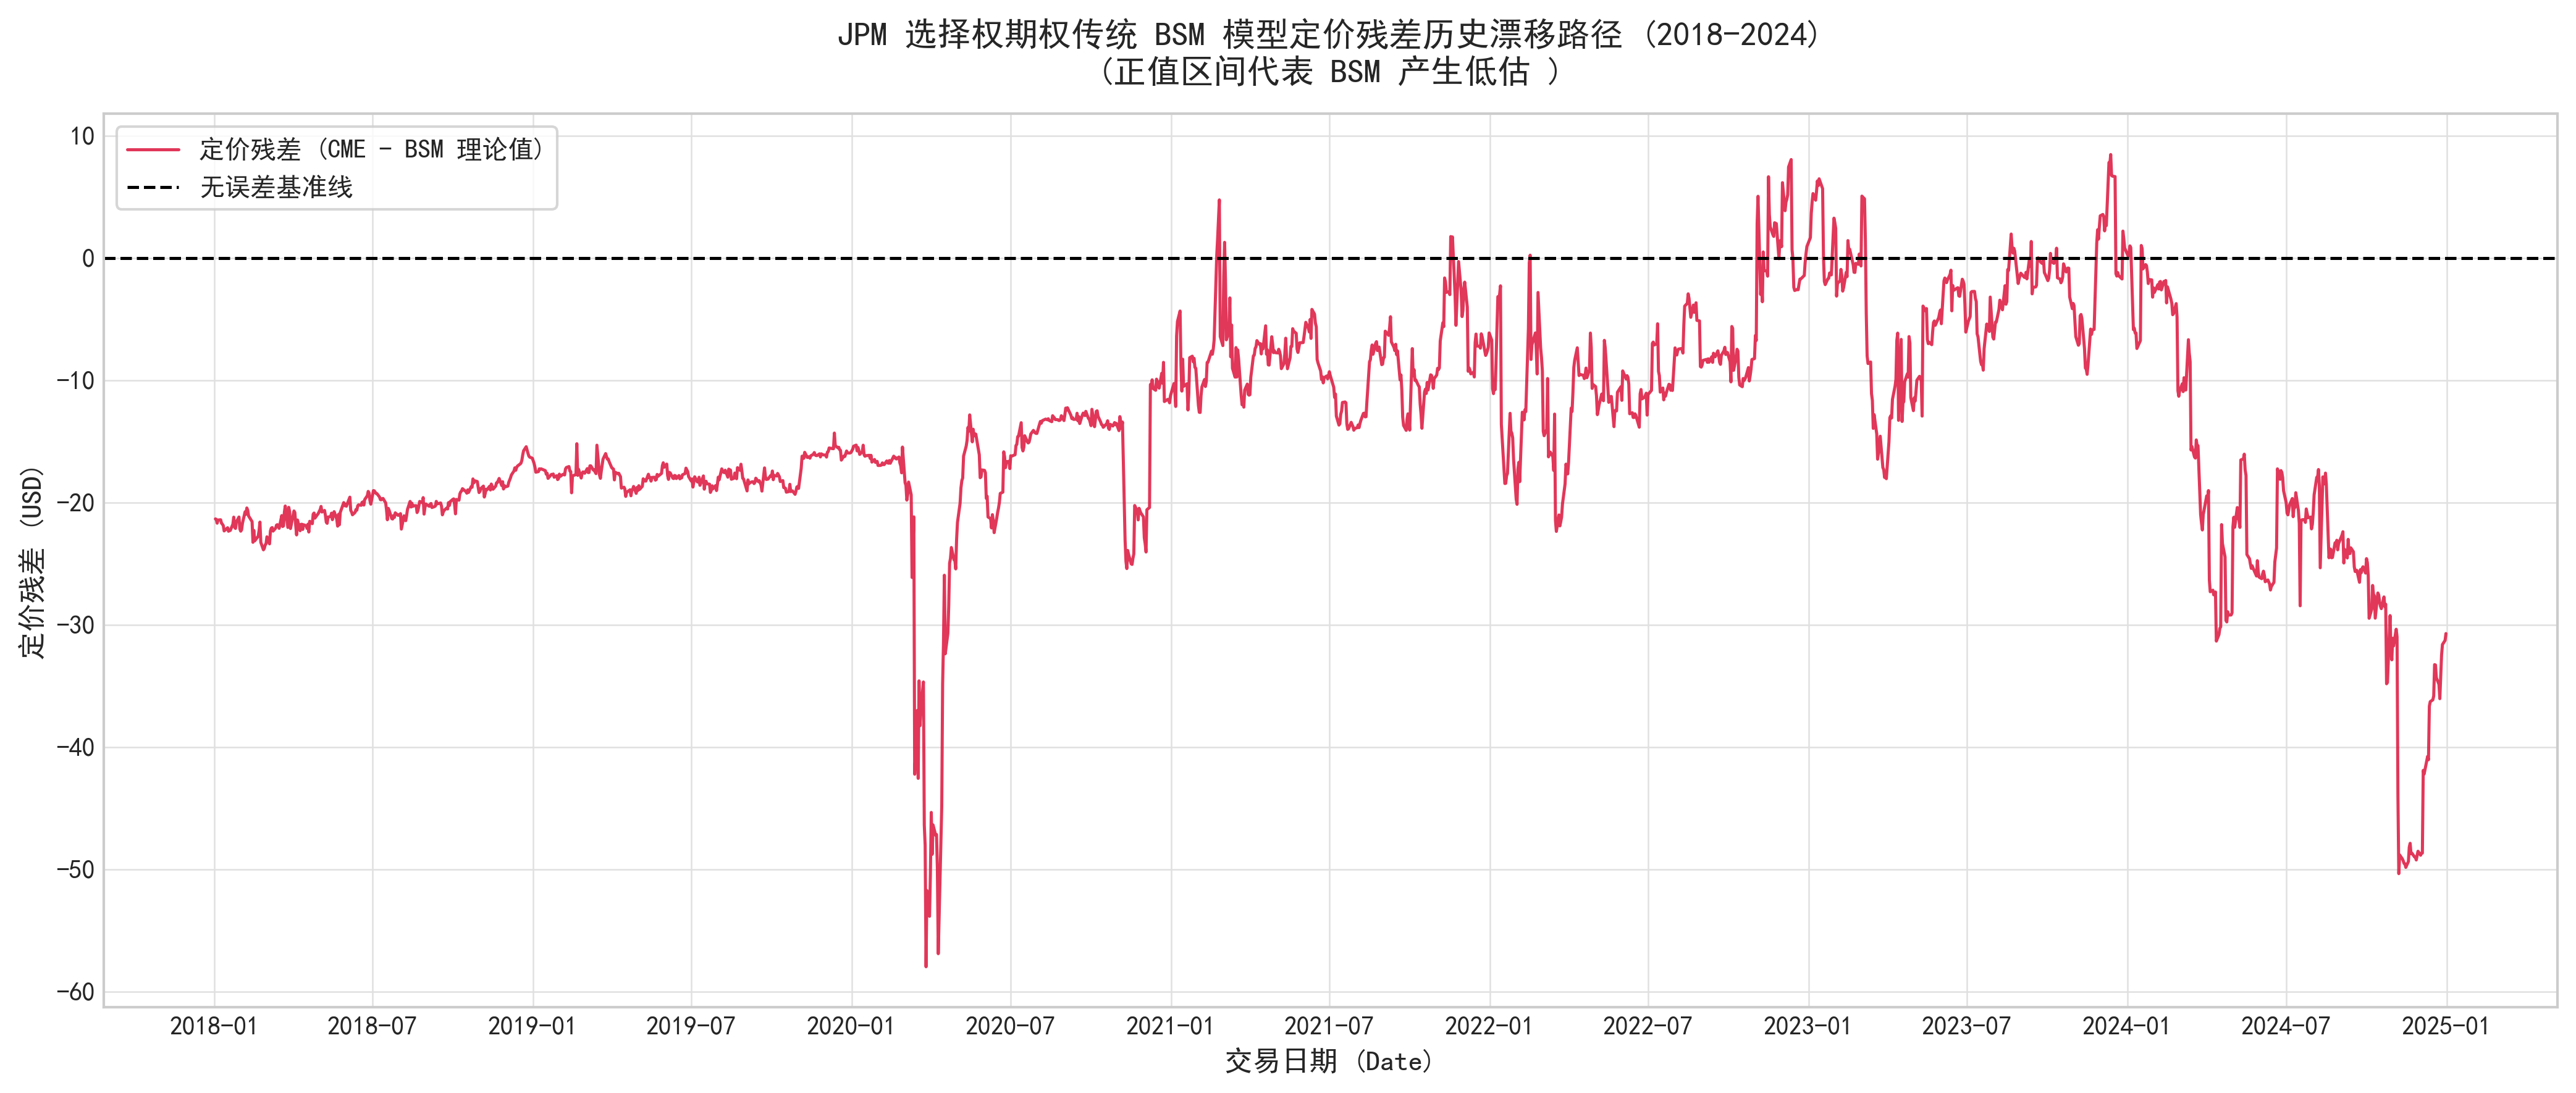

 残差趋势图已成功保存至: D:\Git\Advanced-Chooser-Option-Pricing-Model-with-Real-World-Data-Machine-Learning\notebooks\reports\figures\week4_bsm_residuals.png


In [9]:
# 单元格 : 绘制 BSM 模型定价残差历史漂移路径
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
import pandas as pd

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial']
plt.rcParams['axes.unicode_minus'] = False

# 计算 T1=0.5 的定价残差
df_eval['Residual_T1_0.5'] = df_eval['CME_Actual_Price'] - df_eval['Chooser_BSM_T1_0.5']

fig, ax = plt.subplots(figsize=(14, 6), dpi=300)

# 绘制残差线（正值代表 BSM 模型低估了市场真实价格，即少算了溢价）
ax.plot(df_eval.index, df_eval['Residual_T1_0.5'], color='crimson', label='定价残差 (CME - BSM 理论值)', alpha=0.85, linewidth=1.2)
ax.axhline(0, color='black', linestyle='--', linewidth=1.2, label='无误差基准线')

# 精细化配置
ax.set_title("JPM 选择权期权传统 BSM 模型定价残差历史漂移路径 (2018-2024)\n(正值区间代表 BSM 产生低估 )", fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel("交易日期 (Date)", fontsize=11)
ax.set_ylabel("定价残差 (USD)", fontsize=11)

# 网格线与时间轴优化
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.grid(True, which='major', linestyle='-', linewidth=0.6, color='#e0e0e0')

plt.legend(loc="upper left", frameon=True, facecolor="white")
plt.tight_layout()

# 保存高清残差图
project_root = Path.cwd().parent
output_res_path = project_root / "notebooks" / "reports" / "figures" / "week4_bsm_residuals.png"
plt.savefig(output_res_path, bbox_inches='tight', dpi=300)
plt.show()

print(f" 残差趋势图已成功保存至: {output_res_path}")